In [179]:
import os, shutil, pathlib
import random

import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

In [180]:
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=8
)

val_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=8
)

test_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=8
)

Found 118 files belonging to 2 classes.
Found 24 files belonging to 2 classes.
Found 27 files belonging to 2 classes.


In [181]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))

conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [182]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2)
    ]
)

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_ds,
    epochs=40,
    validation_data=val_ds,
    callbacks=callbacks)

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.5424 - loss: 4.9974 - val_accuracy: 0.4583 - val_loss: 4.3057
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.5000 - loss: 4.7719 - val_accuracy: 0.4167 - val_loss: 4.3114
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.6441 - loss: 3.1718 - val_accuracy: 0.4167 - val_loss: 3.8558
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.6017 - loss: 2.8234 - val_accuracy: 0.4583 - val_loss: 3.9099
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.7288 - loss: 2.2070 - val_accuracy: 0.5833 - val_loss: 3.3394
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.7034 - loss: 2.5611 - val_accuracy: 0.5833 - val_loss: 3.1980
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.6356 - loss: 3.7959 - val_accuracy: 0.5417 - val_loss: 3.0419
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.7288 - loss: 2.3118 - val_accuracy: 0.5833 - val_loss:

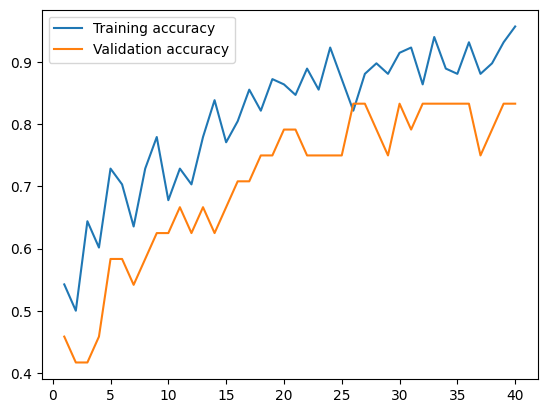

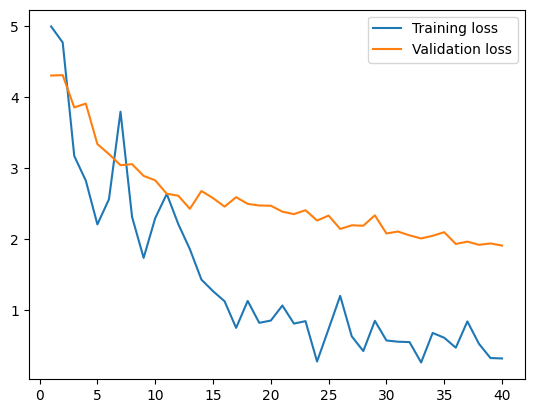

In [183]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

In [184]:
test_model = keras.models.load_model(
    "fine_tuning.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8519 - loss: 0.8689
Test accuracy: 0.851852


Make convolution base model trainable.

In [185]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]

In [186]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.8898 - loss: 0.4858 - val_accuracy: 0.7917 - val_loss: 1.8410
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9576 - loss: 0.3078 - val_accuracy: 0.8333 - val_loss: 1.8001
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.9407 - loss: 0.4061 - val_accuracy: 0.8333 - val_loss: 1.7100
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.9407 - loss: 0.2768 - val_accuracy: 0.8333 - val_loss: 1.8488
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.9576 - loss: 0.1600 - val_accuracy: 0.7500 - val_loss: 1.9432
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9407 - loss: 0.3343 - val_accuracy: 0.8333 - val_loss: 1.6674
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.9746 - loss: 0.1718 - val_accuracy: 0.8333 - val_loss: 1.6544
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.9407 - loss: 0.4315 - val_accuracy: 0.8333 - val_loss:

In [187]:
test_model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8148 - loss: 1.0093
Test accuracy: 0.814815


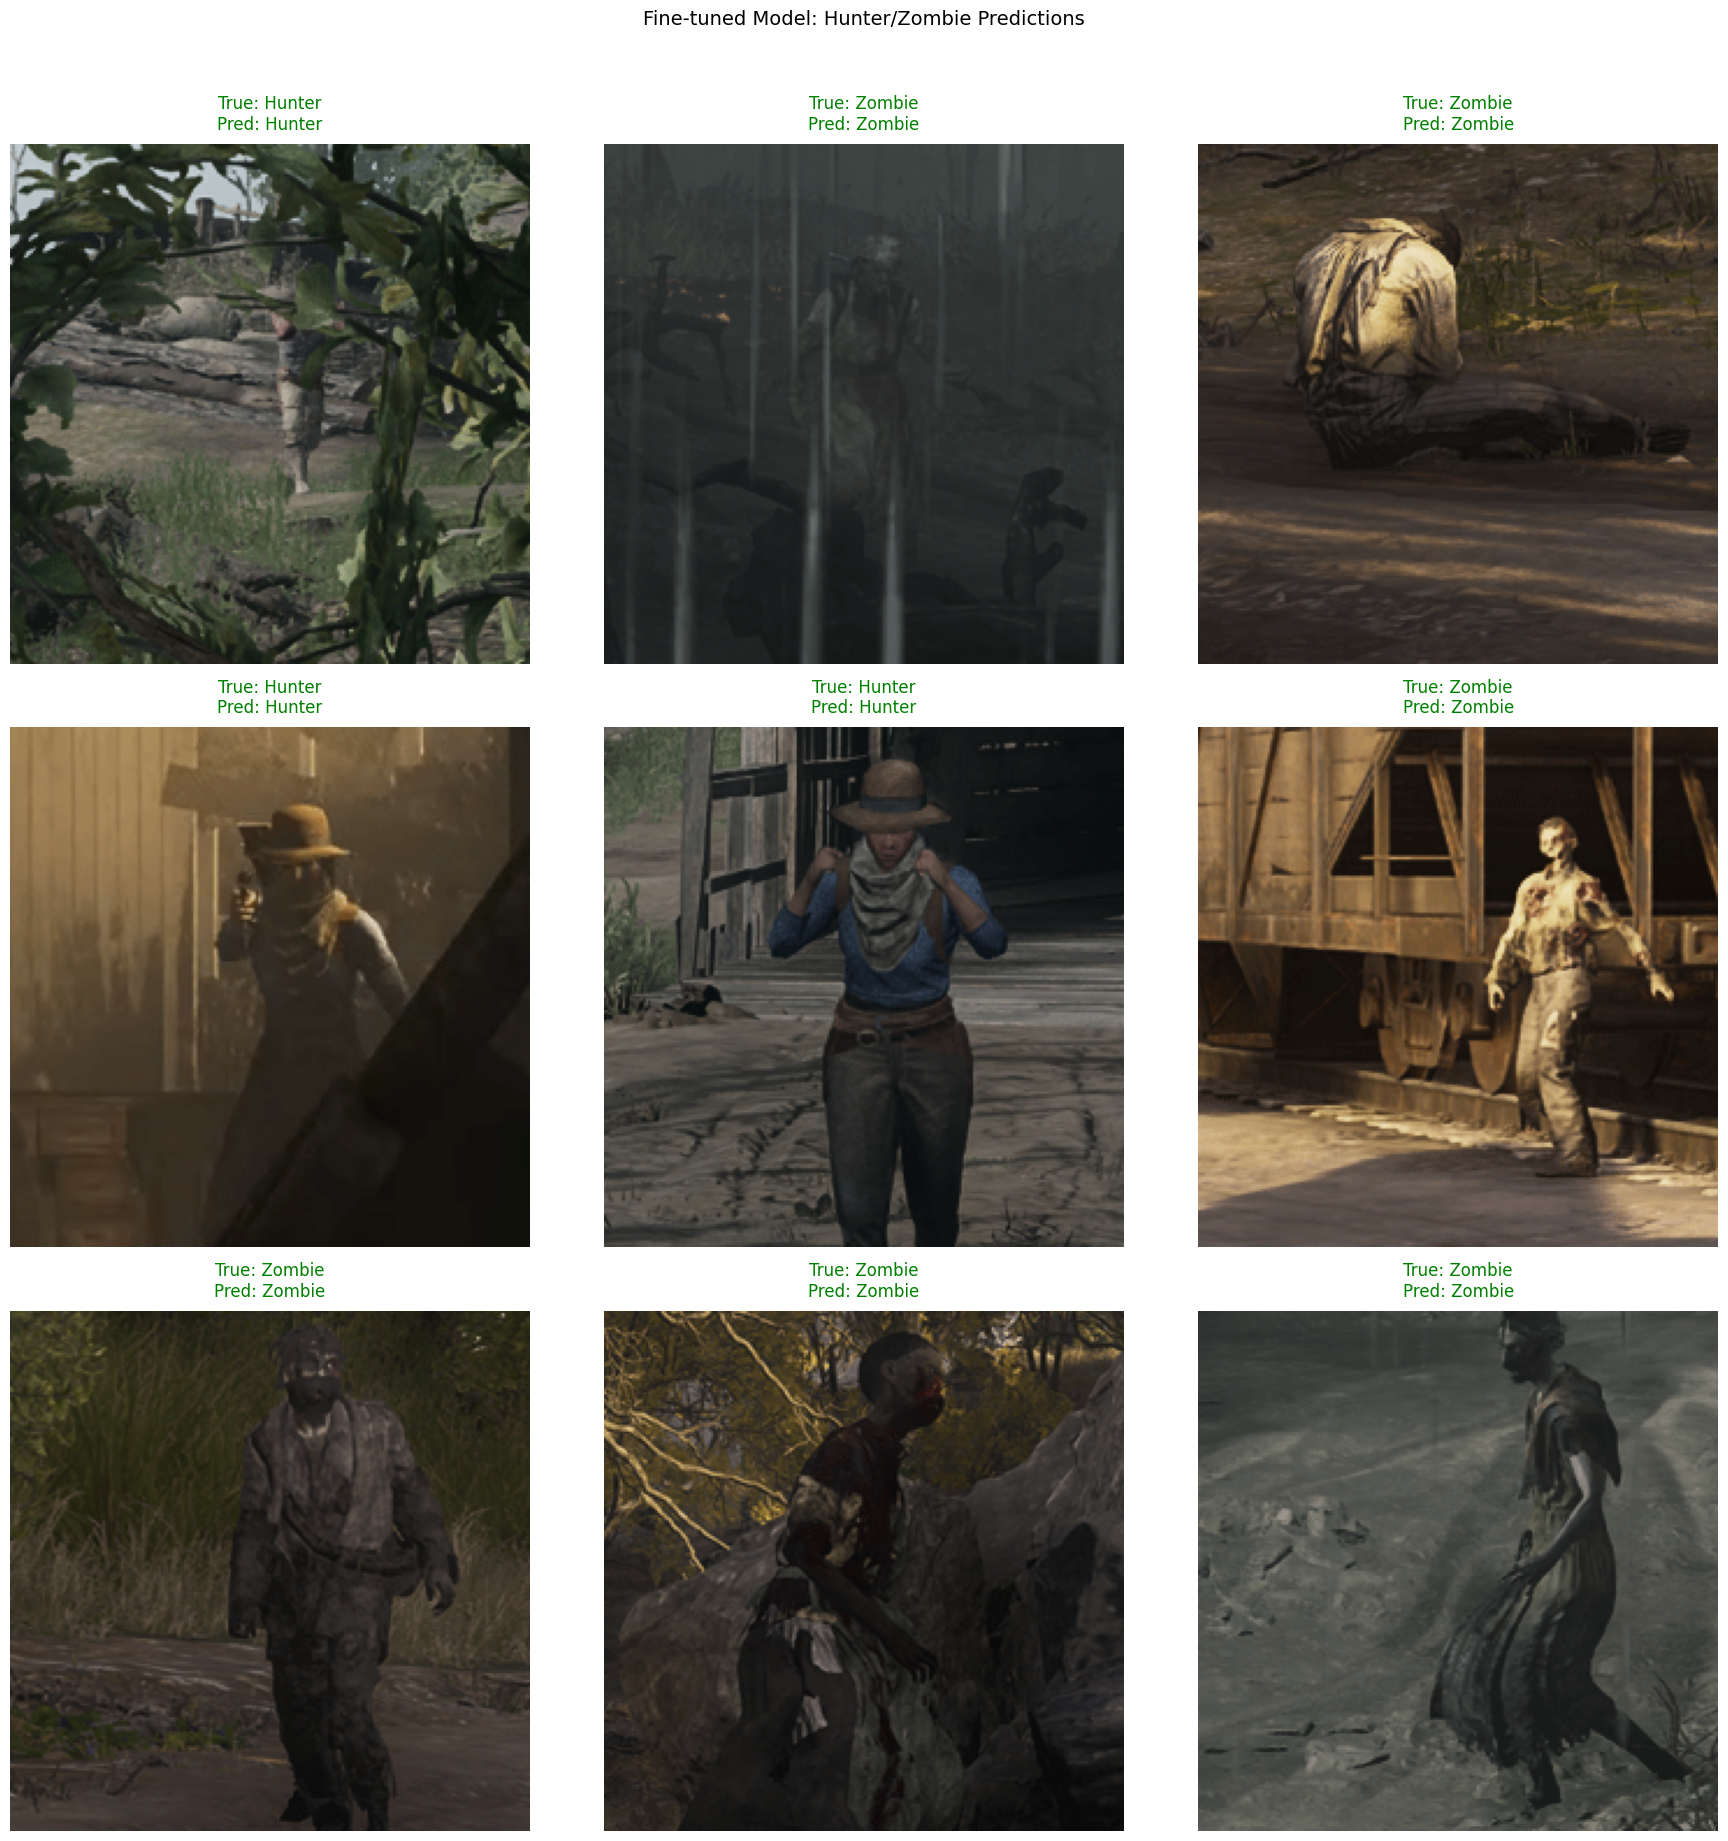

In [188]:
plt.figure(figsize=(18, 18))
subplot_idx = 1

# Take 2 batches from train_ds to get up to 16 images
for batch_idx, (images, labels) in enumerate(train_ds.take(6)):
    # Process the entire batch at once for efficiency
    # The fine-tuned model expects raw images directly
    predictions = test_model.predict(images, verbose=0)
    
    for i in range(len(images)):
        image = images[i]
        true_label = labels[i].numpy()
        prediction = predictions[i][0]
        
        # Class label based on threshold (0.5)
        predicted_class = "Zombie" if prediction > 0.5 else "Hunter"
        
        # Create subplot
        ax = plt.subplot(3, 3, subplot_idx)
        plt.imshow(image.numpy().astype("uint8"))
        plt.axis("off")
        
        # Add title with prediction information and confidence percentage
        title = f"True: {'Zombie' if true_label == 1 else 'Hunter'}\nPred: {predicted_class}"
        
        # Color the title based on prediction correctness
        is_correct = (prediction > 0.5) == (true_label == 1)
        if is_correct:
            plt.title(title, fontsize=12, pad=10, color='green')
        else:
            plt.title(title, fontsize=12, pad=10, color='red')
        
        subplot_idx += 1
        
        # Stop after 9 images
        if subplot_idx > 9:
            break
    
    if subplot_idx > 9:
        break

plt.suptitle("Fine-tuned Model: Hunter/Zombie Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()